In [440]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [441]:
df = pd.read_csv("data/Train_Data.csv")
df

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
0,73564.0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,Adult
1,73568.0,2.0,2.0,20.3,89.0,2.0,80.0,3.85,Adult
2,73576.0,1.0,2.0,23.2,89.0,2.0,68.0,6.14,Adult
3,73577.0,1.0,2.0,28.9,104.0,NaN,84.0,16.15,Adult
4,73580.0,2.0,1.0,35.9,103.0,2.0,81.0,10.92,Adult
...,...,...,...,...,...,...,...,...,...
1961,83711.0,2.0,2.0,33.5,100.0,2.0,73.0,6.53,Adult
1962,83712.0,1.0,2.0,30.0,93.0,2.0,208.0,13.02,Adult
1963,83713.0,1.0,2.0,23.7,103.0,2.0,124.0,21.41,Adult
1964,83718.0,2.0,2.0,27.4,90.0,2.0,108.0,4.99,Adult


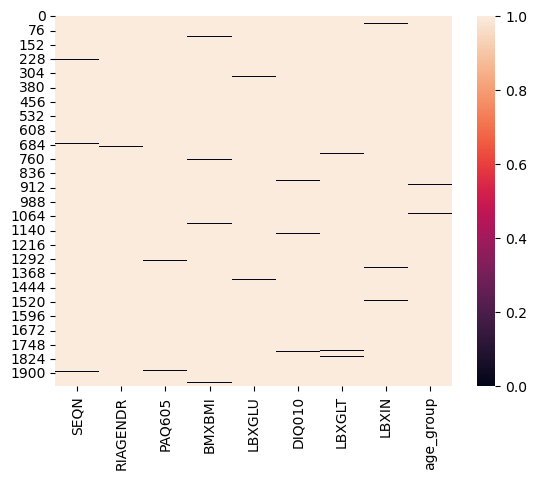

In [442]:
sns.heatmap(df.notna())
df = df.dropna()

In [443]:
lblenc = LabelEncoder()
df['age_group']=lblenc.fit_transform(df['age_group'])

C:\Users\Carlt\AppData\Local\Temp\ipykernel_14512\2856209953.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_group']=lblenc.fit_transform(df['age_group'])


In [444]:
df.drop(['SEQN'], axis=1, inplace=True)

C:\Users\Carlt\AppData\Local\Temp\ipykernel_14512\2513119027.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['SEQN'], axis=1, inplace=True)


<Axes: >

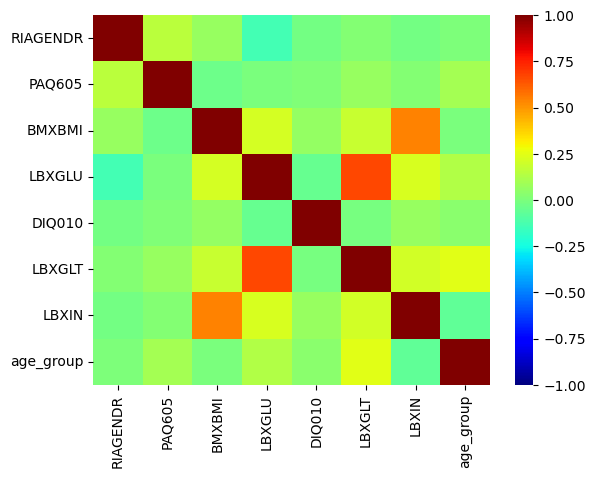

In [445]:
sns.heatmap(df.corr(),cmap="jet", vmin=-1)

<Axes: title={'center': 'Age Group Distribution'}, xlabel='age_group'>

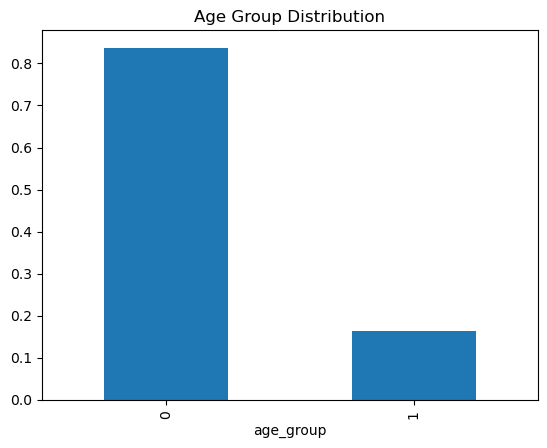

In [446]:
df['age_group'].value_counts(normalize=True).plot(kind='bar', title='Age Group Distribution')

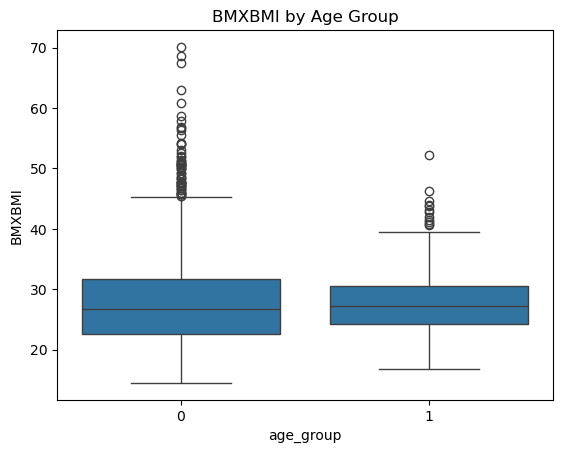

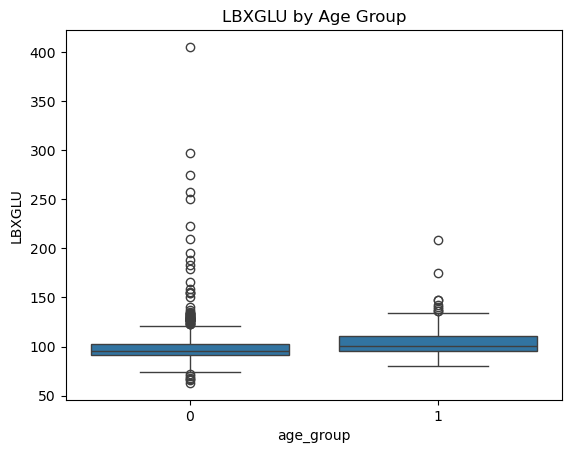

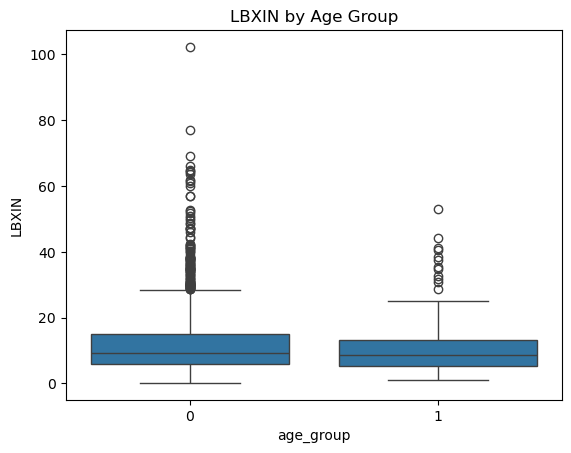

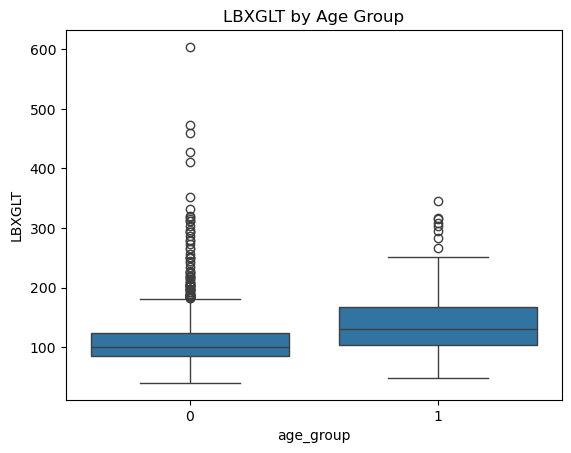

In [447]:
features = ['BMXBMI', 'LBXGLU', 'LBXIN', 'LBXGLT']
for col in features:
    sns.boxplot(x='age_group', y=col, data=df)
    plt.title(f'{col} by Age Group')
    plt.show()


<Axes: xlabel='RIAGENDR'>

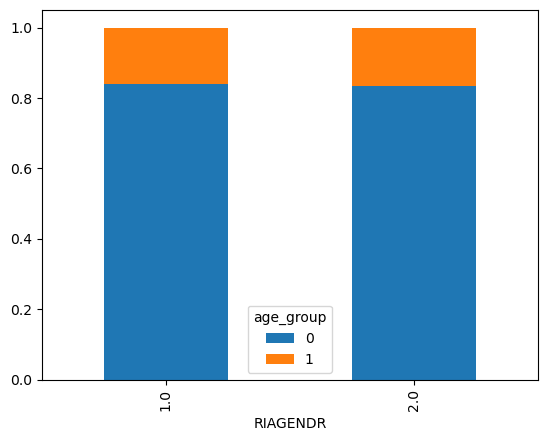

In [448]:
pd.crosstab(df['RIAGENDR'], df['age_group'], normalize='index').plot(kind='bar', stacked=True)

In [449]:
df.corr(numeric_only=True)['age_group'].sort_values(ascending=False)

age_group    1.000000
LBXGLT       0.247725
LBXGLU       0.126331
PAQ605       0.096164
DIQ010       0.033574
RIAGENDR     0.006800
BMXBMI      -0.007708
LBXIN       -0.064305
Name: age_group, dtype: float64

In [450]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]


In [451]:
#remove outliers 
for col in ['BMXBMI', 'LBXGLU', 'LBXIN', 'LBXGLT']:
    df = remove_outliers_iqr(df, col)

In [452]:
df['glucose_to_insulin'] = df['LBXGLU'] / (df['LBXIN'] + 1e-5)
df['bmi_glucose'] = df['BMXBMI'] * df['LBXGLU']
df['BMI_BIN'] = pd.cut(df['BMXBMI'], bins=[0,18.5,25,30,100], labels=['Underweight','Normal','Overweight','Obese'])
df = pd.get_dummies(df, columns=['BMI_BIN'], drop_first=True)
df['GLU_SQ'] = df['LBXGLU'] ** 2


In [453]:
df.corr(numeric_only=True)['age_group'].sort_values(ascending=False)

age_group             1.000000
LBXGLT                0.237286
GLU_SQ                0.148832
LBXGLU                0.146732
PAQ605                0.092331
bmi_glucose           0.089961
BMI_BIN_Overweight    0.082322
BMXBMI                0.044527
glucose_to_insulin    0.032303
RIAGENDR              0.020062
BMI_BIN_Obese        -0.012599
DIQ010               -0.019697
BMI_BIN_Normal       -0.041715
LBXIN                -0.056760
Name: age_group, dtype: float64

In [454]:
df_model = df.loc[:, ['LBXGLT', 'GLU_SQ', 'LBXGLU', 'PAQ605', 'bmi_glucose', 'age_group']]

In [457]:
X = df_model.drop(['age_group'], axis=1)
y = df['age_group']

In [458]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y)

In [459]:
## trying Smote since there is an imbalance
# from imblearn.over_sampling import SMOTE
# oversample = SMOTE(random_state=42)
# X_train, y_train = oversample.fit_resample(X_train, y_train)
#caused a increase in about 0.08 can also be misleading in the f1

Without using smote yeilded better results so not using it


In [460]:
models = {
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}


In [461]:
results = []

for name, model in models.items():
    pipeline = make_pipeline(StandardScaler(), model)
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1 Score': f1
    })

result_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
print(result_df)


c:\Users\Carlt\anaconda3\envs\mlAnalytics\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:46:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 182, number of negative: 1046
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000118 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 473
[LightGBM] [Info] Number of data points in the train set: 1228, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.148208 -> initscore=-1.748722
[LightGBM] [Info] Start training from score -1.748722


c:\Users\Carlt\anaconda3\envs\mlAnalytics\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


               Model  Accuracy  F1 Score
0      Random Forest  0.837662  0.806268
5           CatBoost  0.847403  0.801107
2  Gradient Boosting  0.840909  0.792643
3            XGBoost  0.808442  0.789741
1           AdaBoost  0.840909  0.782733
4           LightGBM  0.801948  0.773103


In [462]:
models_and_parameters = {
    "Random Forest": {
        "model": RandomForestClassifier(),
        "params": {
            "randomforestclassifier__n_estimators": [100, 200],
            "randomforestclassifier__max_depth": [None, 10, 20]
        }
    },
    "AdaBoost": {
        "model": AdaBoostClassifier(),
        "params": {
            "adaboostclassifier__n_estimators": [50, 100],
            "adaboostclassifier__learning_rate": [0.5, 1.0]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        "params": {
            "xgbclassifier__n_estimators": [100, 200],
            "xgbclassifier__max_depth": [3, 6],
            "xgbclassifier__learning_rate": [0.1, 0.3]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(),
        "params": {
            "gradientboostingclassifier__n_estimators": [100, 200],
            "gradientboostingclassifier__max_depth": [3, 5],
            "gradientboostingclassifier__learning_rate": [0.1, 0.2]
        }
    }
}

In [463]:
results = []

for name, mp in models_and_parameters.items():
    print(f"Tuning {name}...")
    pipeline = make_pipeline(StandardScaler(), mp["model"])
    
    grid = GridSearchCV(pipeline, param_grid=mp["params"], cv=3, scoring='f1_weighted', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'Accuracy': acc,
        'F1 Score': f1
    })

result_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
print(result_df)

Tuning Random Forest...


c:\Users\Carlt\anaconda3\envs\mlAnalytics\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Tuning AdaBoost...
Tuning XGBoost...


c:\Users\Carlt\anaconda3\envs\mlAnalytics\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:47:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Tuning Gradient Boosting...
               Model                                        Best Params  \
0      Random Forest  {'randomforestclassifier__max_depth': None, 'r...   
1           AdaBoost  {'adaboostclassifier__learning_rate': 1.0, 'ad...   
2            XGBoost  {'xgbclassifier__learning_rate': 0.1, 'xgbclas...   
3  Gradient Boosting  {'gradientboostingclassifier__learning_rate': ...   

   Accuracy  F1 Score  
0  0.834416  0.800647  
1  0.847403  0.796544  
2  0.827922  0.796399  
3  0.827922  0.789003  


In [464]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
))

              precision    recall  f1-score   support

           0       0.86      0.96      0.91       262
           1       0.31      0.11      0.16        46

    accuracy                           0.83       308
   macro avg       0.59      0.53      0.53       308
weighted avg       0.78      0.83      0.79       308



In [465]:
df_test = pd.read_csv('data/Test_Data.csv')

In [466]:
df_test.drop(['SEQN', 'RIAGENDR'], axis=1, inplace=True)

In [467]:
df_test['glucose_to_insulin'] = df_test['LBXGLU'] / (df_test['LBXIN'] + 1e-5)
df_test['bmi_glucose'] = df_test['BMXBMI'] * df_test['LBXGLU']
df_test['BMI_BIN'] = pd.cut(df_test['BMXBMI'], bins=[0,18.5,25,30,100], labels=['Underweight','Normal','Overweight','Obese'])
df_test = pd.get_dummies(df_test, columns=['BMI_BIN'], drop_first=True)
df_test['GLU_SQ'] = df_test['LBXGLU'] ** 2

In [468]:
df_test = df_test.loc[:, ['LBXGLT', 'GLU_SQ', 'LBXGLU', 'PAQ605', 'bmi_glucose']]

In [469]:
y_test_pred = model.predict(df_test)

In [470]:
result = pd.DataFrame({
    'age_group' :  y_test_pred
})


In [471]:
result.to_csv("submission.csv",index = False)